# 02 · Like-for-like comparison with UXsim (DUO and day-to-day DUE)

Requires the optional dependencies: `pip install -e ".[uxsim,plot]"`.

The comparison is kept fair in four ways:

1. **Same input.** Demand is quantized to multiples of UXsim's platoon size `deltan`, and the
   quantized network is the single input of every method.
2. **Same physics.** UXsim is configured as a point queue: huge jam density (no spillback),
   unthrottled entry, one lane, explicit `capacity_out`, and a dummy sink link behind each
   destination so that the last real link still enforces its capacity.
3. **Same variables.** UXsim output is converted to $(w, y, \pi)$ by departure step: $y$ from vehicle
   logs, $(w, \pi)$ from a time-dependent shortest-path search over counterfactual link travel times
   rebuilt from the logs. The same checker and the same DUE gap are then applied to every method.
4. **Same aggregates.** Total travel time, link volumes, route travel times and wall-clock time use one
   set of formulas.

Methods compared: **DUE-LCP** (this package), **UXsim DUO** (instantaneous shortest path, one run)
and **UXsim DUE** (UXsim's day-to-day `SolverDUE`, several random seeds).

In [1]:
import time

import numpy as np

from rcdue.networks import wakui_5node
from rcdue.one_to_many import (
    check_sequential_result,
    check_solution,
    excess_travel_time,
    solve_sequential,
)
from rcdue.plotting import (
    apply_style,
    plot_due_convergence,
    plot_link_volumes,
    plot_residuals,
    plot_route_equilibrium,
    plot_total_travel_time,
)
from rcdue.uxsim_bridge import (
    UXsimConfig,
    extract_solution,
    lcp_summary,
    quantize_demand,
    run_due,
    run_duo,
)

apply_style()

## Settings

`deltan` is UXsim's platoon size, `reaction_time * deltan` its simulation time step (0.1 min here).
`due_max_iter`, `due_n_routes` and `due_swap_prob` are passed to UXsim's `SolverDUE`.

In [2]:
cfg = UXsimConfig(
    deltan=5, reaction_time=0.02, due_max_iter=50, due_n_routes=8, due_swap_prob=0.10
)
SEEDS = [0, 1, 2]
EPS = 1e-8

## 1. Common input

In [3]:
net_raw = wakui_5node()
net = quantize_demand(net_raw, cfg.deltan)
print(
    f"total demand raw={net_raw.total_demand():.1f}  quantized={net.total_demand():.1f}  (deltan={cfg.deltan})"
)

total demand raw=640.0  quantized=640.0  (deltan=5)


## 2. DUE-LCP

In [4]:
t0 = time.perf_counter()
res = solve_sequential(net, eps=EPS, backend="auto")
t_lcp = time.perf_counter() - t0
rep_lcp = check_sequential_result(net, res, tol=1e-6)
lcp = lcp_summary(net, res)
print(
    f"backend={res.backend} time={t_lcp:.3f}s  TTT={lcp['ttt']:.1f}  "
    f"eq={rep_lcp.equilibrium.max_violation():.1e}  phys={rep_lcp.physical.max_violation():.1e}"
)

backend=gurobi time=0.053s  TTT=16284.6  eq=4.0e-13  phys=7.1e-15


## 3. UXsim DUO and UXsim DUE

Each UXsim run is converted with `extract_solution` into LCP variables plus aggregate statistics.

In [5]:
runs = {"UXsim DUO": [], "UXsim DUE": []}
histories = []
for seed in SEEDS:
    W, t = run_duo(net, cfg, seed=seed)
    runs["UXsim DUO"].append(extract_solution(W, net, elapsed=t))
    W, solver, t = run_due(net, cfg, seed=seed)
    runs["UXsim DUE"].append(extract_solution(W, net, elapsed=t))
    histories.append(
        {
            "seed": seed,
            "ttts": list(map(float, solver.ttts)),
            "t_gaps": list(map(float, solver.t_gaps)),
        }
    )
    print(
        f"seed {seed}: DUO TTT={runs['UXsim DUO'][-1].ttt:.1f} ({runs['UXsim DUO'][-1].elapsed:.1f}s)   "
        f"DUE TTT={runs['UXsim DUE'][-1].ttt:.1f} ({runs['UXsim DUE'][-1].elapsed:.1f}s, {cfg.due_max_iter} iters)"
    )

solving DUE...


DUE summary:
 total travel time: initial 19117.0 -> average of last 12 iters 16660.0
 number of potential route changes: initial 185.0 -> average of last 12 iters 0.8
 route travel cost gap: initial 6.2 -> average of last 12 iters 0.0
 computation time: 11.9 seconds
seed 0: DUO TTT=19117.0 (0.9s)   DUE TTT=16663.0 (11.9s, 50 iters)


solving DUE...


DUE summary:
 total travel time: initial 19117.0 -> average of last 12 iters 16663.0
 number of potential route changes: initial 185.0 -> average of last 12 iters 0.0
 route travel cost gap: initial 6.2 -> average of last 12 iters 0.0
 computation time: 11.5 seconds
seed 1: DUO TTT=19117.0 (0.3s)   DUE TTT=16663.0 (11.5s, 50 iters)


solving DUE...


DUE summary:
 total travel time: initial 19117.0 -> average of last 12 iters 16252.2
 number of potential route changes: initial 360.0 -> average of last 12 iters 99.2
 route travel cost gap: initial 10.8 -> average of last 12 iters 0.3
 computation time: 12.1 seconds
seed 2: DUO TTT=19117.0 (0.3s)   DUE TTT=16203.0 (12.1s, 50 iters)


## 4. Same residuals and the same DUE gap for every method

`excess_travel_time` is the mean travel time per user in excess of the shortest-path time at the
same departure time (0 at an exact DUE). Unlike UXsim's internal time gap, it is evaluated against
the true shortest path over the whole network, not only over the enumerated route set.

In [6]:
reports = {"DUE-LCP": [rep_lcp]}
excess = {"DUE-LCP": [excess_travel_time(net, res.w, res.y, res.pi, res.pi_nodes)]}
ttt = {"DUE-LCP": [lcp["ttt"]]}
elapsed = {"DUE-LCP": [t_lcp]}
for method, sols in runs.items():
    reports[method] = [
        check_solution(net, s.w, s.y, s.pi, s.pi_nodes, tol=1e-6) for s in sols
    ]
    excess[method] = [excess_travel_time(net, s.w, s.y, s.pi, s.pi_nodes) for s in sols]
    ttt[method] = [s.ttt for s in sols]
    elapsed[method] = [s.elapsed for s in sols]

print(
    f"{'method':10s} {'TTT':>10s} {'time[s]':>9s} {'excess/veh':>11s} {'eq gap':>9s} {'phys gap':>9s}"
)
for m in reports:
    print(
        f"{m:10s} {np.mean(ttt[m]):10.1f} {np.mean(elapsed[m]):9.2f} {np.mean(excess[m]):11.3f} "
        f"{np.mean([r.equilibrium.max_violation() for r in reports[m]]):9.2e} "
        f"{np.mean([r.physical.max_violation() for r in reports[m]]):9.2e}"
    )

method            TTT   time[s]  excess/veh    eq gap  phys gap
DUE-LCP       16284.6      0.05       0.000  3.99e-13  7.11e-15
UXsim DUO     19117.0      0.48      11.286  5.87e+02  3.17e-01
UXsim DUE     16509.7     11.82       1.154  1.51e+02  5.33e-01


## 5. Link volumes and total travel time

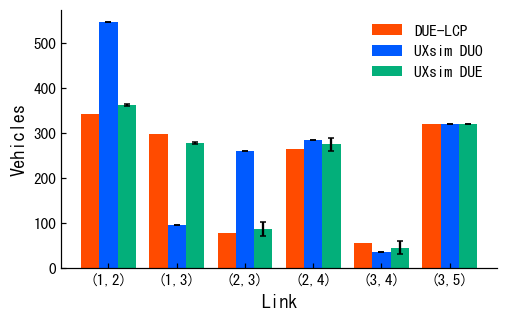

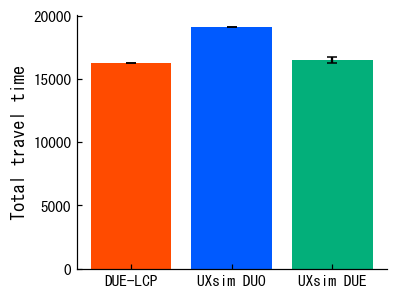

In [7]:
fig = plot_link_volumes(net, lcp["link_volumes"], runs)
fig = plot_total_travel_time(ttt)

## 6. Equilibrium residuals

DUE-LCP satisfies every condition to round-off. The simulation-based assignments satisfy conservation
and $R_y \ge 0$ but violate the complementarity conditions; the day-to-day DUE reduces
$y \cdot R_y$ relative to DUO.

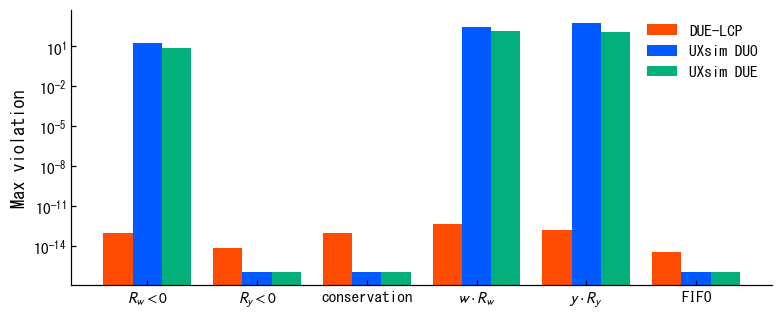

In [8]:
fig = plot_residuals(reports)

## 7. Convergence of UXsim's day-to-day DUE

Left: total travel time per iteration (dashed: DUE-LCP). Right: UXsim's own time gap per vehicle.
Runs may stall at a state where no vehicle finds a faster route within its enumerated route set
while the network-wide excess travel time above is still positive.

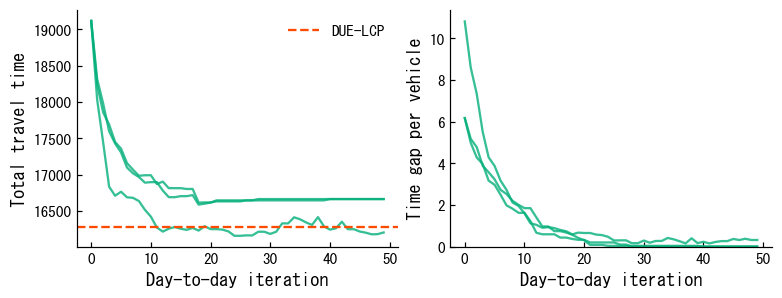

In [9]:
fig = plot_due_convergence(histories, lcp["ttt"])

## 8. Route-choice equilibrium per OD pair (paper Figs. 3, 4), all methods

For UXsim, the travel time of every route (used or not) is the counterfactual value for a departure at
the end of each demand bin, and the band marks bins in which vehicles actually used the route
(first seed shown).

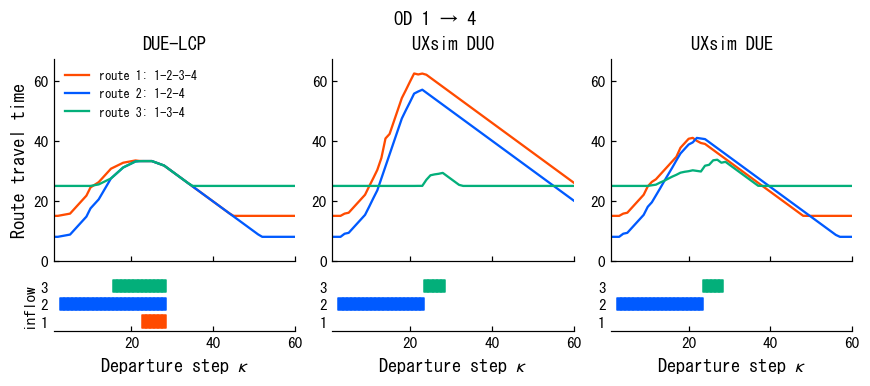

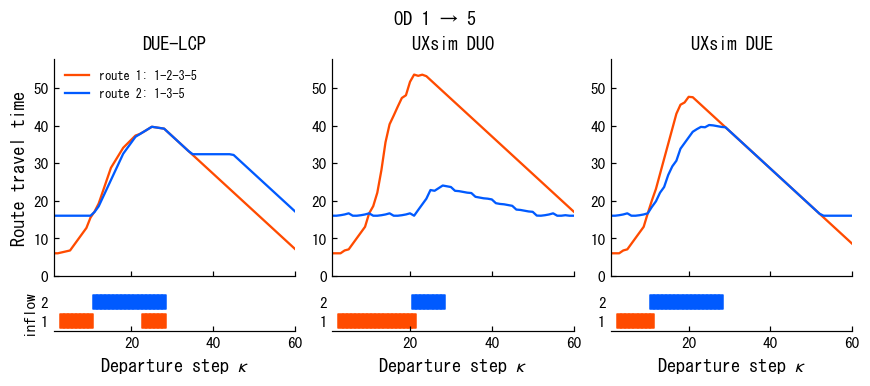

In [10]:
for d in net.destinations:
    fig = plot_route_equilibrium(net, res, d, uxsim_runs=runs)